# Part A

In [23]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(67)
x = np.linspace(-3, 3, 101)
y = (x**3 - 2*x**2 + 5) + np.random.normal(0, 2, len(x))

def lls_vs_poly(y_actual, y_pred):
    MSE = np.mean((y_actual - y_pred)**2)
    sum_of_squares_res = np.sum((y_actual - y_pred)**2)
    sum_of_squares_tot = np.sum((y_actual - np.mean(y_actual))**2)
    r2 = 1 - (sum_of_squares_res / sum_of_squares_tot)
    return MSE, r2

coeff_lin = np.polyfit(x, y, 1)
y_lin = np.polyval(coeff_lin, x)
mse_lin, r2_lin = lls_vs_poly(y, y_lin)

coeff_poly = np.polyfit(x, y, 3)
y_poly = np.polyval(coeff_poly, x)
mse_poly, r2_poly = lls_vs_poly(y, y_poly)

print(f"Linear -> MSE: {mse_lin:.4f}, R2: {r2_lin:.4f}")
print(f"Cubic -> MSE: {mse_poly:.4f}, R2: {r2_poly:.4f}")

better_method = "Cubic Polynomial" if mse_poly < mse_lin else "Linear"
print(f"{better_method} is the better fit")

Linear -> MSE: 49.1225, R2: 0.6609
Cubic -> MSE: 3.3233, R2: 0.9771
Cubic Polynomial is the better fit


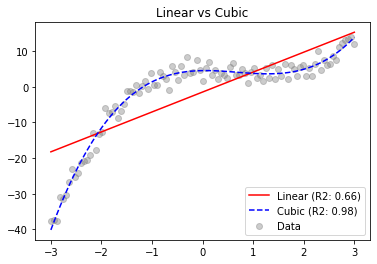

In [15]:
plt.scatter(x, y, color='gray', alpha=0.4, label='Data')
plt.plot(x, y_lin, 'r-', label=f'Linear (R2: {r2_lin:.2f})')
plt.plot(x, y_poly, 'b--', label=f'Cubic (R2: {r2_poly:.2f})')
plt.title("Linear vs Cubic")
plt.legend()
plt.show()

# Part B

Degree  1 ; MSE: 49.1225 ; R2: 0.6609
Degree  3 ; MSE: 3.3233 ; R2: 0.9771
Degree 25 ; MSE: 2.6782 ; R2: 0.9815


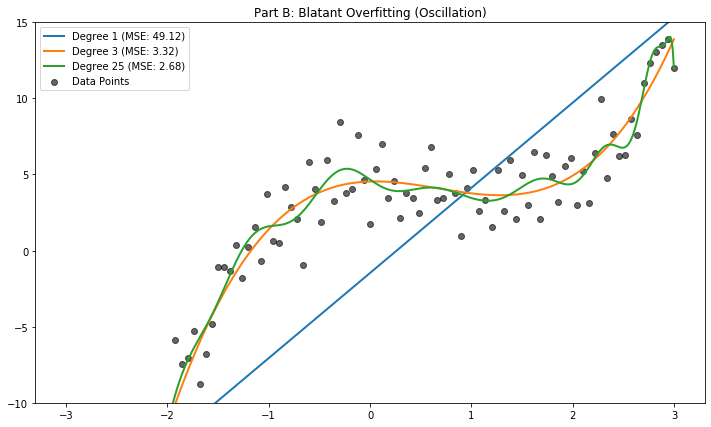

In [38]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(67)
x = np.linspace(-3, 3, 101) 
y = (x**3 - 2*x**2 + 5) + np.random.normal(0, 2, len(x))

def calculate_metrics(y_actual, y_pred):
    mse = np.mean((y_actual - y_pred)**2)
    r2 = 1 - (np.sum((y_actual - y_pred)**2) / np.sum((y_actual - np.mean(y_actual))**2))
    return mse, r2

x2 = np.linspace(-3, 3, 500)

plt.figure(figsize=(12, 7))
plt.scatter(x, y, color='black', alpha=0.6, label='Data Points')

for d in [1, 3, 25]:
    coeffs = np.polyfit(x, y, d)
    
    y_pred_metrics = np.polyval(coeffs, x)
    MSE, R2 = calculate_metrics(y, y_pred_metrics)
    
    y2 = np.polyval(coeffs, x_smooth)
    
    plt.plot(x2, y2, label=f"Degree {d} (MSE: {MSE:.2f})", linewidth=2)
    print(f"Degree {d:2} ; MSE: {MSE:.4f} ; R2: {R2:.4f}")

plt.title("Part B: Blatant Overfitting (Oscillation)")
plt.ylim(-10, 15)
plt.legend()
plt.show()

# Part C

In [39]:
degree = 3

V = np.vander(x, degree + 1)
coeffs_vander, residuals_v, rank, s = np.linalg.lstsq(V, y, rcond=None)
y_vander = V @ coeffs_vander
mse_v, r2_v = calculate_metrics(y, y_vander)

print(f"Coefficients: {coeffs_vander}")
print(f"MSE: {mse_v:.5f}")
print(f"R-Squared: {r2_v:.5f}")

Coefficients: [ 0.97778606 -1.96486824  0.20805558  4.5400064 ]
MSE: 3.32328
R-Squared: 0.97706


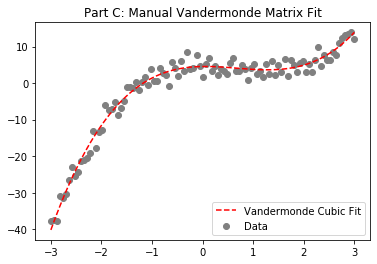

In [40]:
plt.scatter(x, y, color='gray', label='Data')
plt.plot(x, y_vander, 'r--', label='Vandermonde Cubic Fit')
plt.title("Part C: Manual Vandermonde Matrix Fit")
plt.legend()
plt.show()